In [110]:
# 1. INSTALLASI LIBRARY
!pip install folium contextily geopandas plotly scikit-learn

In [85]:
# 2. menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [86]:
# 3. IMPORT LIBRARY LENGKAP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.stats import shapiro
import folium
from folium.plugins import HeatMap
import geopandas as gpd
import contextily as ctx
import plotly.express as px
from mpl_toolkits.axes_grid1 import make_axes_locatable
sns.set_style('whitegrid')

In [87]:
# 4. Loading Dataset
df = pd.read_csv("/content/gdrive/MyDrive/Praktikum02/Praktikum11/data/AB_NYC_2019.csv")

In [88]:
# 5. Mengetahui informasi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [89]:
# 6. Melihat 5 baris awal
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [90]:
# 7. DATA CLEANING (missing + duplikat)
print("\n=== DATA CLEANING ===")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplikat: {df.duplicated().sum()}")
df_clean = df[['id', 'name', 'host_id', 'neighbourhood_group', 'latitude', 'longitude',
               'room_type', 'price', 'minimum_nights', 'number_of_reviews',
               'calculated_host_listings_count', 'availability_365']].dropna()
df_clean = df_clean.drop_duplicates()
print(f"Shape setelah cleaning: {df_clean.shape}")



=== DATA CLEANING ===
Missing values: 20141
Duplikat: 0
Shape setelah cleaning: (48879, 12)


In [91]:
# 8. Data Cleaning (Pembersihan Data)
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [92]:
# 9. Melihat data duplikat
df.duplicated().sum()

np.int64(0)

In [93]:
# 10. EDA LENGKAP - HEATMAP GPS

print("\n=== EDA - HEATMAP SEBARAN AIRBNB NYC ===")
m1 = folium.Map(location=[40.7128, -74.0060], zoom_start=11)
HeatMap(data=df_clean[['latitude', 'longitude']].values.tolist(), radius=15, blur=20).add_to(m1)
m1.save('heatmap_airbnb_nyc.html')
m1


=== EDA - HEATMAP SEBARAN AIRBNB NYC ===



=== EDA - PETA PRICE per Neighbourhood ===


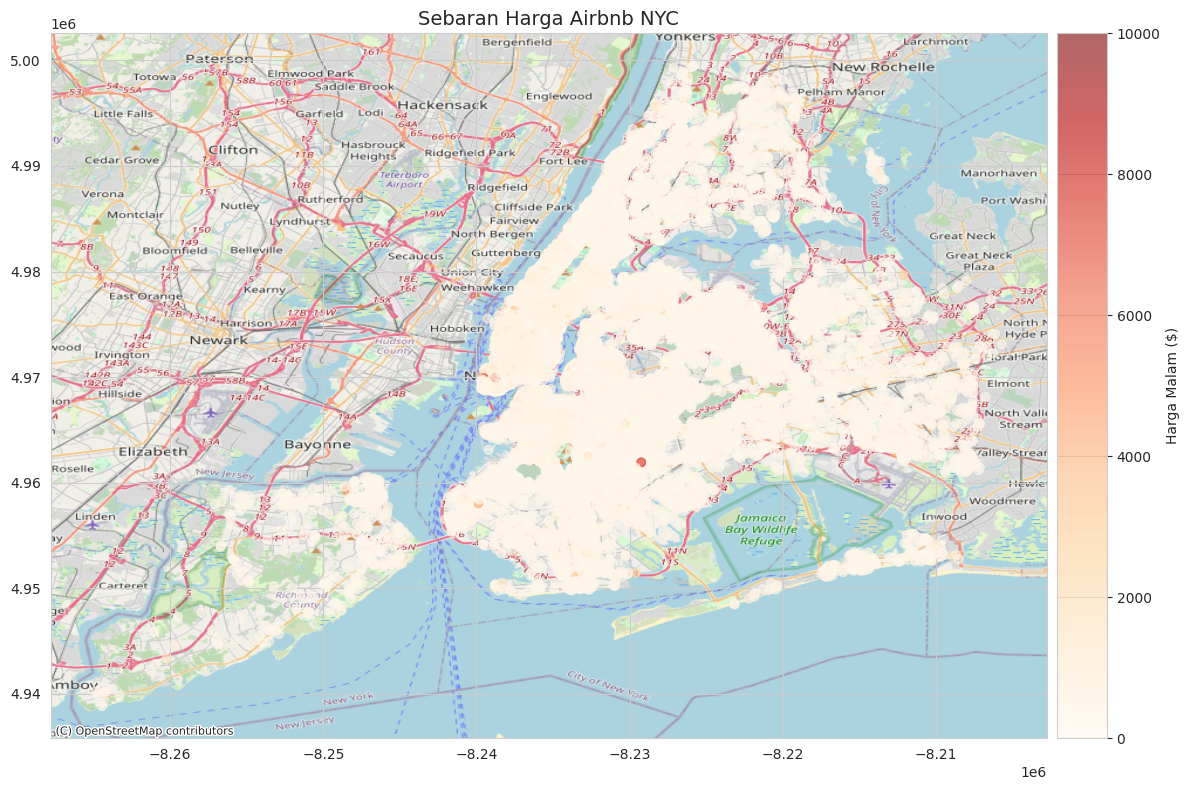

In [94]:
# 11. EDA - PETA SEBARAN PRICE dengan GeoPandas + Contextily
print("\n=== EDA - PETA PRICE per Neighbourhood ===")
gdf = gpd.GeoDataFrame(df_clean, geometry=gpd.points_from_xy(df_clean.longitude, df_clean.latitude))
gdf.set_crs(epsg=4326, inplace=True)
gdf = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

scatter = ax.scatter(gdf.geometry.x, gdf.geometry.y, c=df_clean['price'],
                    cmap='OrRd', s=40, alpha=0.6)
gdf.explore(ax=ax, column='price', cmap='OrRd', alpha=0.3)
ctx.add_basemap(ax, crs=gdf.crs, source=ctx.providers.OpenStreetMap.Mapnik)
plt.colorbar(scatter, cax=cax, label='Harga Malam ($)')
ax.set_title('Sebaran Harga Airbnb NYC', fontsize=14)
plt.tight_layout()
plt.show()

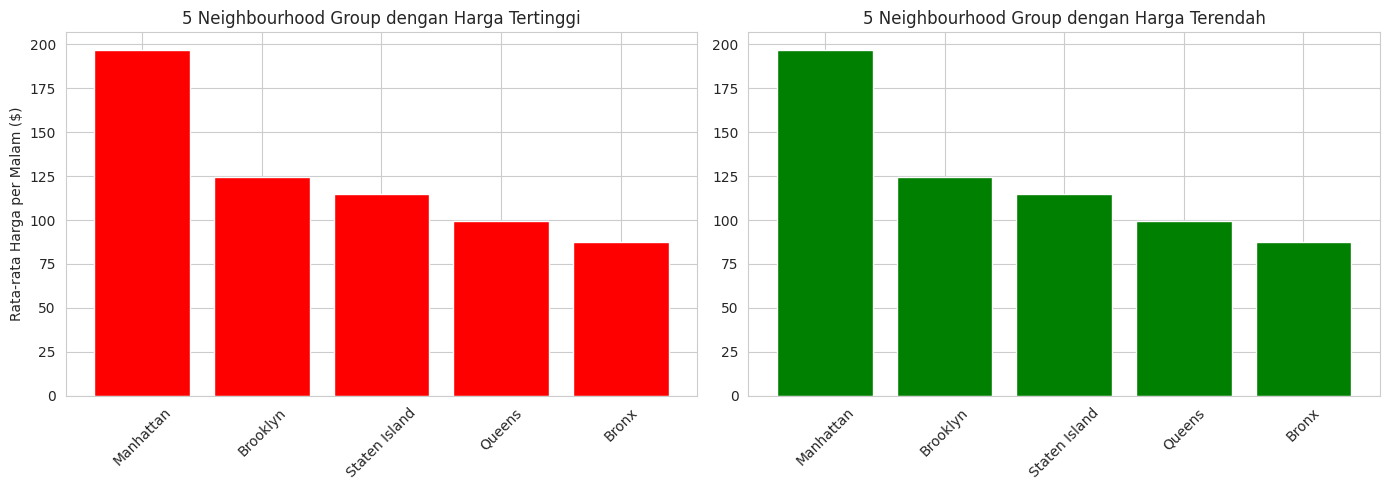

In [95]:
# 12. Grafik Bar Harga Tertinggi & Terendah per Neighbourhood_Group ===
# hitung rata-rata harga per neighbourhood_group
price_ng = df_clean.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)

# ambil 5 teratas dan 5 terbawah
top5 = price_ng.head(5)
bottom5 = price_ng.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# grafik bar 5 termahal
axes[0].bar(top5.index, top5.values, color='red')
axes[0].set_title('5 Neighbourhood Group dengan Harga Tertinggi')
axes[0].set_ylabel('Rata-rata Harga per Malam ($)')
axes[0].tick_params(axis='x', rotation=45)

# grafik bar 5 termurah
axes[1].bar(bottom5.index, bottom5.values, color='green')
axes[1].set_title('5 Neighbourhood Group dengan Harga Terendah')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [96]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

Columns in gdf_map before merge: Index(['BoroCode', 'BoroName', 'Shape_Leng', 'Shape_Area', 'geometry'], dtype='object')


,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330385.03697,1.623853e+09,"MULTIPOLYGON (((-74.05051 40.56642, -74.05047 ..."
1,4,Queens,861038.47930,3.049947e+09,"MULTIPOLYGON (((-73.83668 40.59495, -73.83678 ..."
2,3,Brooklyn,726568.94634,1.959432e+09,"MULTIPOLYGON (((-73.86706 40.58209, -73.86769 ..."
3,1,Manhattan,358532.95642,6.364422e+08,"MULTIPOLYGON (((-74.01093 40.68449, -74.01193 ..."
4,2,Bronx,464517.89055,1.186804e+09,"MULTIPOLYGON (((-73.89681 40.79581, -73.89694 ..."


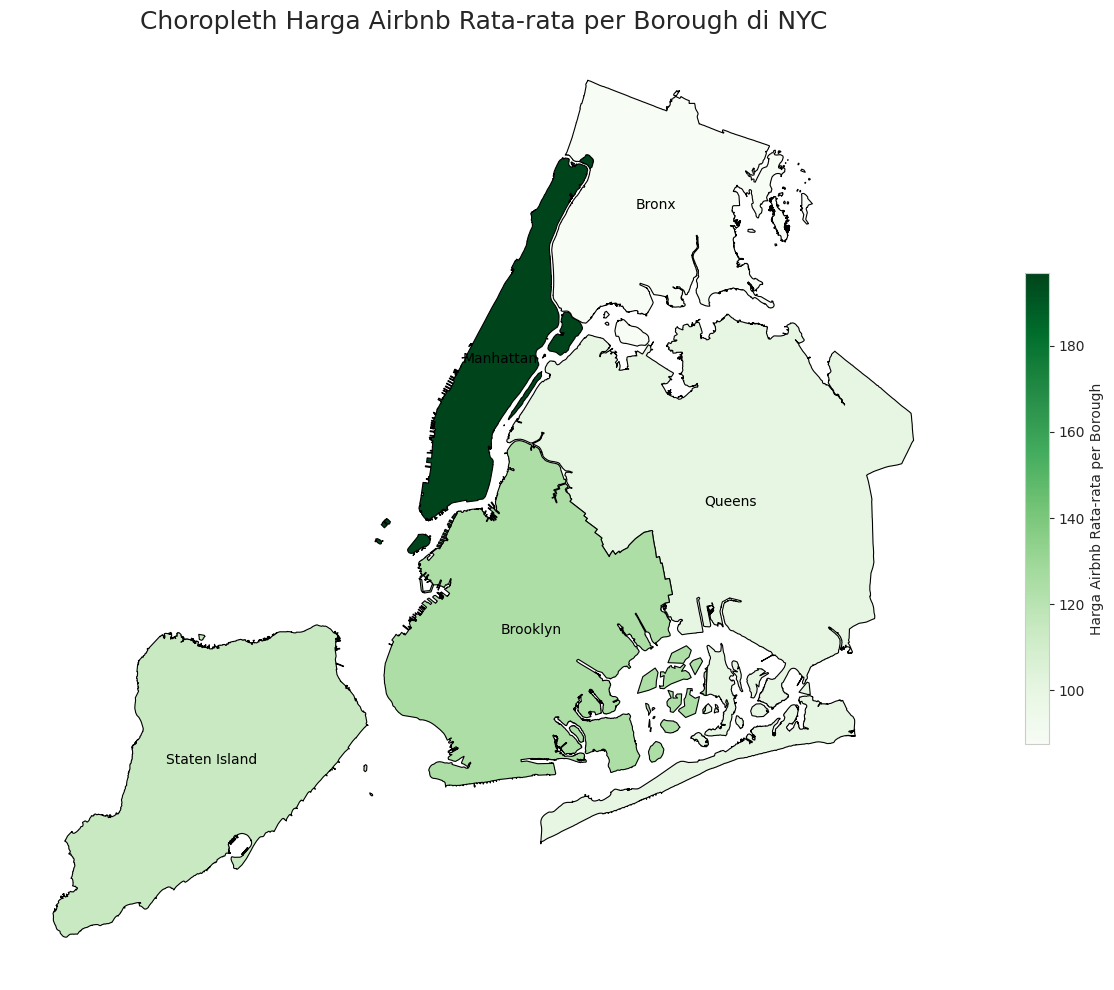

In [97]:
# 14. Visualisasi Rata-rata Price per Borough (mirip SALARY per Provinsi)

# 1) Download shapefile batas borough NYC
!wget -q "https://raw.githubusercontent.com/dwillis/nyc-maps/master/boroughs.geojson" -O nyc_boroughs.geojson

# 2) Baca shapefile
gdf_map = gpd.read_file("nyc_boroughs.geojson")

# (opsional) cek struktur
print("Columns in gdf_map before merge:", gdf_map.columns)
display(gdf_map.head())

# 3) Hitung rata-rata harga per borough dari data Airbnb
avg_price = df.groupby('neighbourhood_group')['price'].mean().reset_index()

# 4) Join shapefile dengan data rata-rata price
gdf_choro = gdf_map.merge(avg_price, left_on='BoroName', right_on='neighbourhood_group')

# 5) Plot choropleth
fig, ax = plt.subplots(figsize=(14, 10))

gdf_choro.plot(
    column='price',
    cmap='Greens',        # sama seperti SALARY per provinsi di modul
    linewidth=0.8,
    edgecolor='black',
    legend=True,
    ax=ax,
    legend_kwds={
        'label': "Harga Airbnb Rata-rata per Borough",
        'orientation': "vertical",
        'shrink': 0.5
    }
)

# 6) Tambahkan label nama borough di tengah poligon
for idx, row in gdf_choro.iterrows():
    plt.annotate(
        text=row['BoroName'],
        xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
        ha='center',
        fontsize=10,
        color='black'
    )

ax.set_title("Choropleth Harga Airbnb Rata-rata per Borough di NYC", fontsize=18)
ax.axis('off')
plt.tight_layout()
plt.show()


In [98]:
# 15. from scipy.stats import shapiro

# 1. Buang kolom non-numerik
normality_test_df = df_clean.drop(
    columns=['id', 'name', 'host_id', 'room_type', 'neighbourhood_group', 'latitude', 'longitude']
)

normality_test_df.info()  # ini mirip contoh di PDF: cek tinggal kolom numerik

# 2. Uji Shapiro-Wilk per kolom
for col in normality_test_df.columns:
    stat, p = shapiro(normality_test_df[col].sample(5000, random_state=0))  # sampling kalau datanya besar
    print(f"{col}: statistik = {stat:.4f}, p-value = {p:.4f}")

<class 'pandas.core.frame.DataFrame'>
Index: 48879 entries, 0 to 48894
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   price                           48879 non-null  int64
 1   minimum_nights                  48879 non-null  int64
 2   number_of_reviews               48879 non-null  int64
 3   calculated_host_listings_count  48879 non-null  int64
 4   availability_365                48879 non-null  int64
dtypes: int64(5)
memory usage: 2.2 MB
price: statistik = 0.2665, p-value = 0.0000
minimum_nights: statistik = 0.1800, p-value = 0.0000
number_of_reviews: statistik = 0.5585, p-value = 0.0000
calculated_host_listings_count: statistik = 0.1950, p-value = 0.0000
availability_365: statistik = 0.7935, p-value = 0.0000


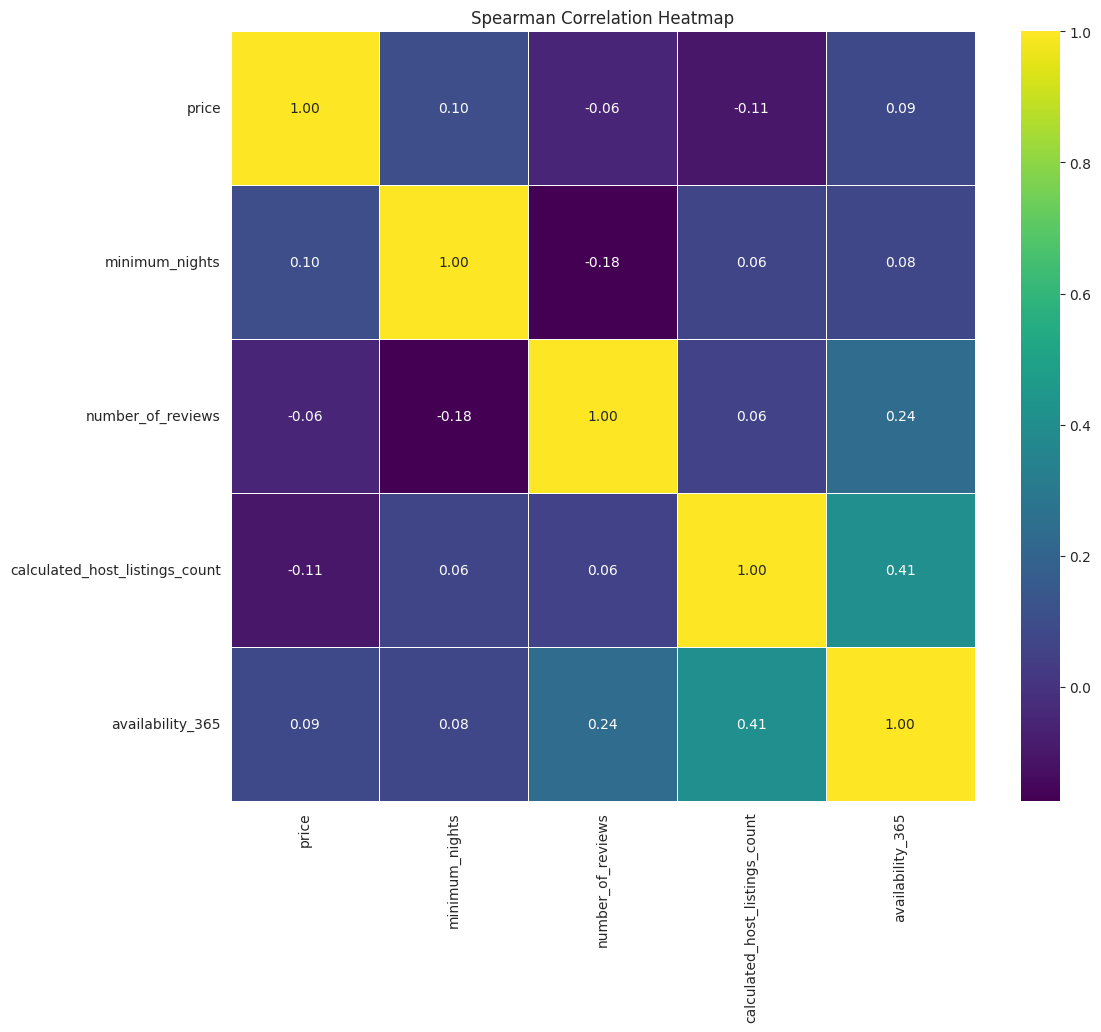

In [99]:
# 16. KORELASI SPEARMAN

correlation_df = normality_test_df

correlation_matrix = correlation_df.corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='viridis',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Spearman Correlation Heatmap")
plt.show()

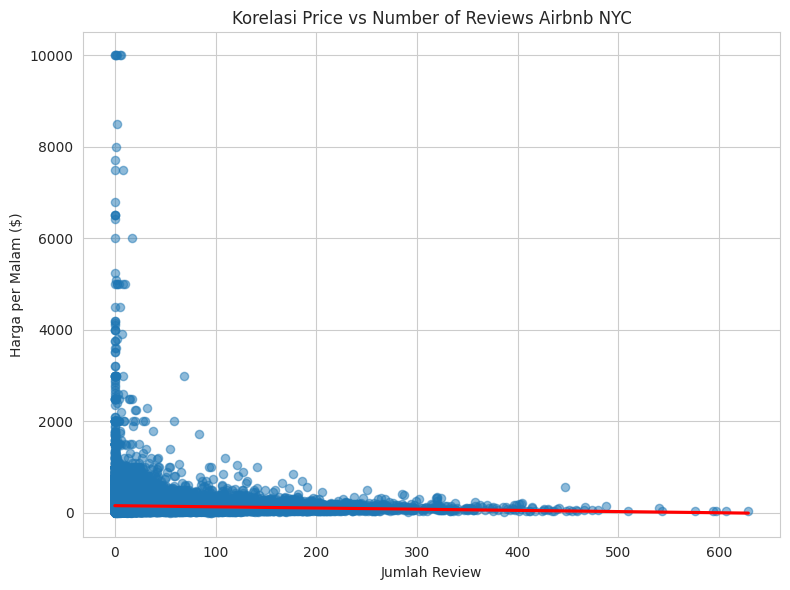

In [100]:
# 17. Analisis Korelasi Spesifik: Price vs Number of Reviews (analog IPM vs UHH)

plt.figure(figsize=(8, 6))
sns.regplot(
    data=df_clean,
    x='number_of_reviews',
    y='price',
    scatter_kws={'alpha': 0.5, 's': 35},
    line_kws={'color': 'red'}
)
plt.title('Korelasi Price vs Number of Reviews Airbnb NYC')
plt.xlabel('Jumlah Review')
plt.ylabel('Harga per Malam ($)')
plt.tight_layout()
plt.show()

In [101]:
# 18. Pemilihan Kolom untuk Normalisasi

print("=== 11.1 Pemilihan Kolom untuk Normalisasi ===")

# pilih hanya fitur numerik yang akan dipakai DBSCAN
cols_for_scaling = [
    'price',
    'minimum_nights',
    'number_of_reviews',
    'calculated_host_listings_count',
    'availability_365'
]

normalisasi_df = df_clean[cols_for_scaling].copy()
normalisasi_df.info()


=== 11.1 Pemilihan Kolom untuk Normalisasi ===
<class 'pandas.core.frame.DataFrame'>
Index: 48879 entries, 0 to 48894
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   price                           48879 non-null  int64
 1   minimum_nights                  48879 non-null  int64
 2   number_of_reviews               48879 non-null  int64
 3   calculated_host_listings_count  48879 non-null  int64
 4   availability_365                48879 non-null  int64
dtypes: int64(5)
memory usage: 2.2 MB


In [102]:
# 19. Proses Normalisasi dengan RobustScaler

from sklearn.preprocessing import RobustScaler

print("\n=== 11.2 Proses Normalisasi dengan RobustScaler ===")

scaler = RobustScaler()

# fit + transform
X_scaled_array = scaler.fit_transform(normalisasi_df)

# ubah lagi ke DataFrame agar enak dipakai
X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=cols_for_scaling,
    index=df_clean.index
)

print("5 baris pertama setelah normalisasi:")
display(X_scaled.head())

print("\nRingkasan statistik setelah normalisasi:")
display(X_scaled.describe())


=== 11.2 Proses Normalisasi dengan RobustScaler ===
5 baris pertama setelah normalisasi:


,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,0.405660,-0.50,0.173913,5.0,1.409692
1,1.122642,-0.50,1.739130,1.0,1.365639
2,0.415094,0.00,-0.217391,0.0,1.409692
3,-0.160377,-0.50,11.521739,0.0,0.656388
4,-0.245283,1.75,0.173913,0.0,-0.198238



Ringkasan statistik setelah normalisasi:


,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
count,48879.000000,48879.000000,48879.000000,48879.000000,48879.000000
mean,0.440777,1.002757,0.794835,6.145891,0.298630
std,2.265913,5.004000,1.937224,32.957738,0.579794
min,-1.000000,-0.500000,-0.217391,0.000000,-0.198238
25%,-0.349057,-0.500000,-0.173913,0.000000,-0.198238
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.650943,0.500000,0.826087,1.000000,0.801762
max,93.339623,311.750000,27.130435,326.000000,1.409692


=== 20. Menentukan Epsilon dengan K-Distance Graph ===


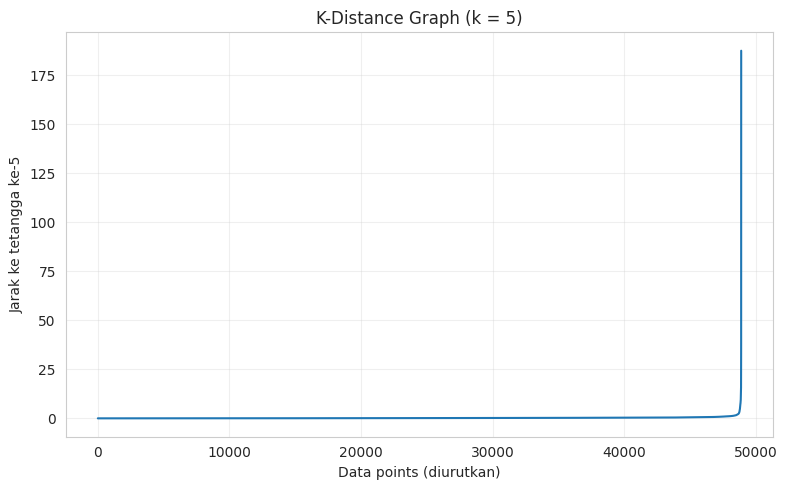

In [103]:
# 20. Menentukan Parameter ε (epsilon) menggunakan K-Distance Graph

print("=== 20. Menentukan Epsilon dengan K-Distance Graph ===")

min_samples = 5   # ini sama dengan min_samples yang nanti dipakai di DBSCAN

# 1. Fit k-nearest neighbors pada data yang sudah dinormalisasi
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)

# 2. Hitung jarak ke tetangga ke-k untuk setiap titik
distances, indices = neighbors_fit.kneighbors(X_scaled)

# ambil kolom ke-(k-1), lalu urutkan
k_distances = np.sort(distances[:, min_samples - 1])

# 3. Plot k-distance graph
plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Graph (k = {min_samples})')
plt.xlabel('Data points (diurutkan)')
plt.ylabel(f'Jarak ke tetangga ke-{min_samples}')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [104]:
# 21. Clustering dengan DBSCAN

from sklearn.cluster import DBSCAN

print("=== 11. Clustering dengan DBSCAN ===")

# menggunakan data yang sudah dinormalisasi
normalisasi_df = X_scaled.copy()

# set parameter dari hasil K-Distance Graph
eps_value = 0.8    # ganti dengan nilai epsilon yang kamu dapat dari grafik (contoh: 0.8)
min_samples = 5    # sama dengan k di K-Distance Graph

# inisialisasi dan jalankan DBSCAN
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
labels = dbscan.fit_predict(normalisasi_df.values)

# simpan label cluster ke dataframe utama
df_clean["Cluster_DBSCAN"] = labels

# lihat jumlah anggota tiap cluster (termasuk noise = -1)
print(df_clean["Cluster_DBSCAN"].value_counts())

=== 11. Clustering dengan DBSCAN ===
Cluster_DBSCAN
 2      31624
 1       6447
 4       2528
-1       1190
 3       1190
        ...  
 77         5
 74         5
 117        5
 130        5
 100        4
Name: count, Length: 132, dtype: int64


In [105]:
# 22. Evaluasi Kualitas Clustering menggunakan Silhouette Score

from sklearn.metrics import silhouette_score

mask = labels != -1            # hilangkan noise (label -1)
score = silhouette_score(normalisasi_df[mask], labels[mask])

print("Silhouette Score:", score)

Silhouette Score: 0.1049776888663122


/tmp/ipython-input-1419363875.py:36: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



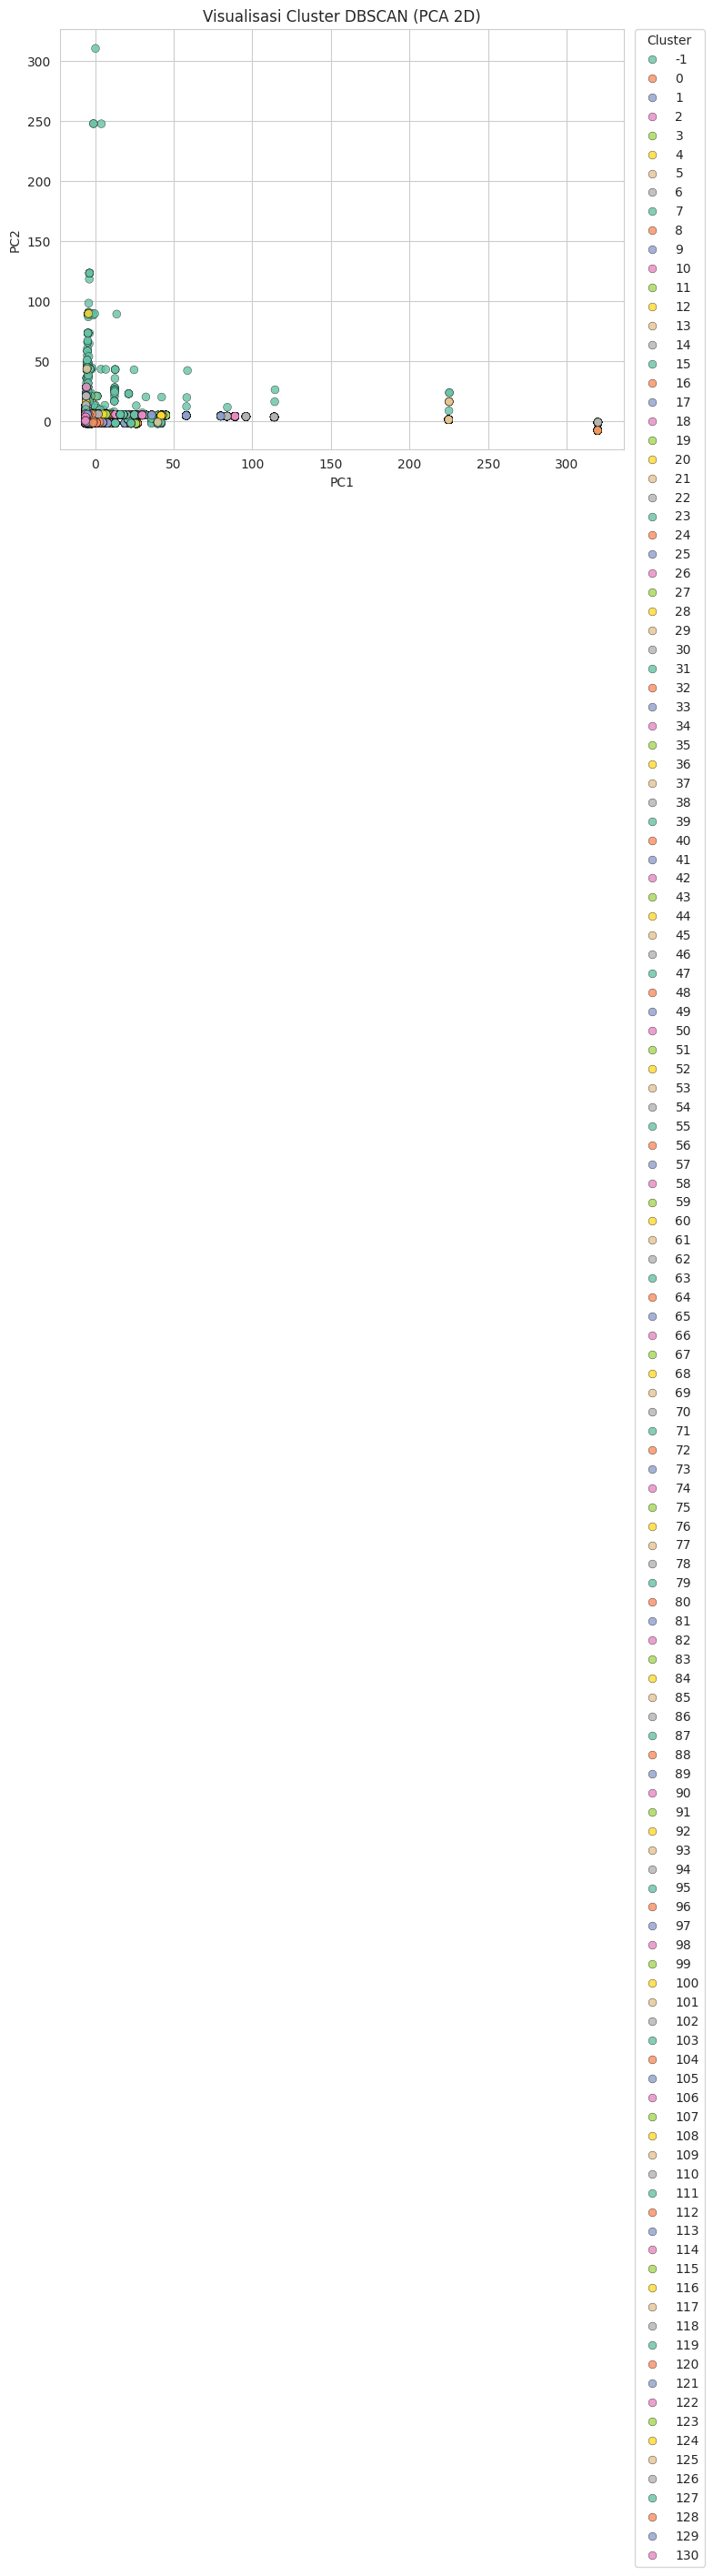

In [106]:
# 23. Visualisasi Hasil Clustering dengan PCA (2D)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# PCA ke 2 dimensi
pca = PCA(n_components=2)
reduced = pca.fit_transform(normalisasi_df)

plt.figure(figsize=(8, 6))

scatter_ax = sns.scatterplot(
    x=reduced[:, 0],
    y=reduced[:, 1],
    hue=labels,
    palette="Set2",
    s=40,
    alpha=0.8,
    edgecolor="k",
    linewidth=0.3
)

plt.title("Visualisasi Cluster DBSCAN (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")

# pindahkan legend ke luar (kanan) plot
plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()


In [107]:
# 24. Pengelompokan Kualitatif Cluster

def klasifikasi_db(x):
    if x == 0:
        return "Baik"
    elif x == -1:
        return "Noise"
    else:
        return "Kurang"

df_clean['Klasifikasi_DBSCAN'] = df_clean['Cluster_DBSCAN'].apply(klasifikasi_db)

print(df_clean['Klasifikasi_DBSCAN'].value_counts())

Klasifikasi_DBSCAN
Kurang    47319
Noise      1190
Baik        370
Name: count, dtype: int64


In [108]:
# 25. Analisis Lanjutan per Cluster (Cluster Summary)

print("=== 15. Analisis Lanjutan per Cluster (Cluster Summary) ===")

cols_numeric = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "calculated_host_listings_count",
    "availability_365"
]

cluster_summary_db = (
    df_clean
    .groupby("Klasifikasi_DBSCAN")[cols_numeric]
    .mean()
    .round(2)
)

print(cluster_summary_db)

=== 15. Analisis Lanjutan per Cluster (Cluster Summary) ===
                     price  minimum_nights  number_of_reviews  \
Klasifikasi_DBSCAN                                              
Baik                 78.07            1.96              24.84   
Kurang              140.08            6.16              22.12   
Noise               678.61           42.41              68.94   

                    calculated_host_listings_count  availability_365  
Klasifikasi_DBSCAN                                                    
Baik                                          6.00            210.06  
Kurang                                        7.15            109.75  
Noise                                         7.47            203.19  


In [109]:
# 26. Visualisasi Interaktif Persebaran Cluster (Plotly

import plotly.express as px
import pandas as pd

print("=== Visualisasi Interaktif Persebaran Cluster (Plotly) ===")

# 1. Siapkan DataFrame untuk Plotly (PCA 2D + label cluster + info lokasi)
df_pca_db = pd.DataFrame(reduced, columns=["PCA 1", "PCA 2"])
df_pca_db["Klasifikasi_DBSCAN"] = df_clean["Klasifikasi_DBSCAN"].values   # Baik/Kurang/Noise
df_pca_db["Lokasi"] = df_clean["neighbourhood_group"].values              # bisa diganti kolom lain, misal 'name'

# 2. Scatter interaktif
fig = px.scatter(
    df_pca_db,
    x="PCA 1",
    y="PCA 2",
    color="Klasifikasi_DBSCAN",   # warna per kategori cluster
    hover_name="Lokasi",          # teks yang muncul saat di-hover
    title="Persebaran Data Berdasarkan Klasifikasi (DBSCAN)",
    width=900,
    height=600
)

fig.show()


=== Visualisasi Interaktif Persebaran Cluster (Plotly) ===
